In [1]:
import MDAnalysis as mda
from numpy import *
import os
from pylab import *
import MDAnalysis.analysis.distances
import MDAnalysis.analysis.rms
from MDAnalysis.analysis import align
import glob
#import umap
import scipy.stats
import sklearn
import sklearn.decomposition
import sklearn.preprocessing
import pandas as pd
import seaborn as sns
from MDAnalysis.analysis.hydrogenbonds.hbond_analysis import HydrogenBondAnalysis as HBA

In [10]:
import os

########################################################
#############      FOR NOW EQPOINT IS 0   ##############
########################################################
EQPOINT=0

systemFolders = glob.glob("huNumbering/*t5a*/")

systemgros=[]
systemtprs=[]
systemtrjs=[]
for i in range(len(systemFolders)):
    systemgros.append(sorted(glob.glob(systemFolders[i]+"*.gro")))
    systemtprs.append(sorted(glob.glob(systemFolders[i]+"*.tpr")))
    systemtrjs.append(sorted(glob.glob(systemFolders[i]+"*.xtc")))


    
    
threeColor=["#FE6100","#332288","#882255"]
colourScheme= threeColor
system_names = ["rhT5A","T5A","T5AR332P"]
systems=[]
for i in range(len(systemgros)):
    sub=[]
    for j in range(len(systemgros[i])):
        # When using TPRs, residues are indexed from 1; so we need to add in the first residue, 1 - 1 + first resid=first resid
        #firstres = mda.Universe(systemgros[i][j]).residues.resids[0]-1
        tu = mda.Universe(systemgros[i][j],systemtrjs[i][j])
        #tu.residues.resids +=firstres
                          
        sub.append(tu)
        
    systems.append(sub)


bodys=[]
bodystrings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []
    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and not ("+combinedLoopString+")"))
        sub2.append("protein and not ("+combinedLoopString+")")
        
    bodys.append(sub)
    bodystrings.append(sub2)
    
    
v1s=[]
v1strings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []

    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and "+combinedLoopString))
        sub2.append("protein and "+combinedLoopString)

        
    v1s.append(sub)        
    v1strings.append(sub2)
                   
        
        
v2s=[]
v2strings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 380:400"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []

    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and "+combinedLoopString))
        sub2.append("protein and "+combinedLoopString)

        
    v2s.append(sub)        
    v2strings.append(sub2)

C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\topology\base.py:203: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  residx = np.zeros_like(criteria[0], dtype=np.int)
C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\core\selection.py:640: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: h

In [5]:
# Ok let's do PCA
def getPairwiseDists(systems,datasets,selection_strings,stride = 10,EQPOINT=250):
    
    alldists=[]
    for i in range(len(datasets)):
        subdists=[]
        for j in range(len(datasets[i])):
            distances=[]
            for k in range(int(EQPOINT/stride),int(len(systems[i][j].trajectory)/stride)):
                systems[i][j].trajectory[k*stride]
                distances.append(MDAnalysis.analysis.distances.self_distance_array(datasets[i][j].select_atoms("name CA").positions))
            subdists.append(distances)
        alldists.append(subdists)
    return alldists


v1dists = getPairwiseDists(systems[1:],v1s[1:],v1strings[1:],stride = 10,EQPOINT=EQPOINT)

v1shaped_dists=[]
v1pca_colours = []
#for i in range(len(dists)):
for j in range(len(v1dists[0])):
    for k in range(len(v1dists[0][j])):
        v1shaped_dists.append(v1dists[0][j][k])
        v1pca_colours.append(colourScheme[0+1])



v1Z=sklearn.preprocessing.StandardScaler().fit_transform(v1shaped_dists)


C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\core\selection.py:521: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  mask = np.zeros(len(group), dtype=np.bool)


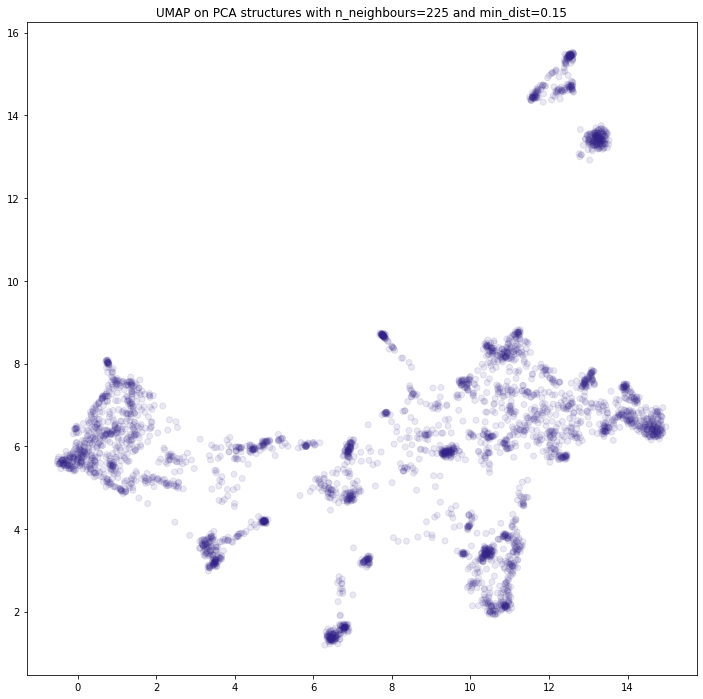

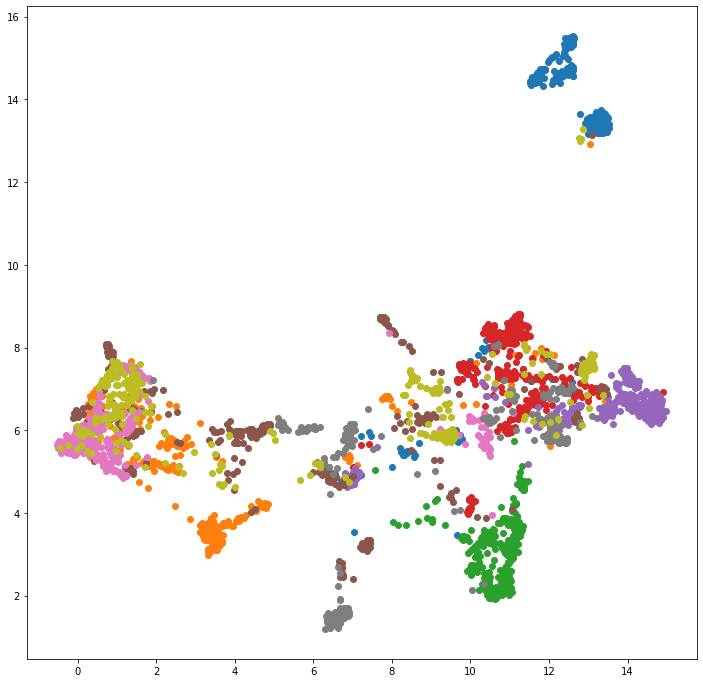

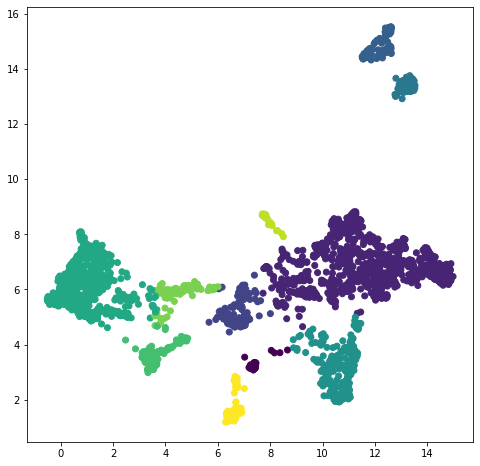

In [9]:
import umap 
v1reducer = umap.UMAP(n_neighbors=225,
                                min_dist=0.15,
                                transform_seed = 1,
                                random_state = 1)

v1embedding = reducer.fit_transform(v1Z)


figure(figsize = (12,12))

scatter(*v1embedding.T,color = v1pca_colours,alpha = 0.1)
title("UMAP on PCA structures with n_neighbours="+str(225)+" and min_dist="+str(0.15))

figure(figsize = (12,12))
for i in range(9):
    scatter(array(v1embedding).reshape(-1,2).T[0].T[i*400:400*(i+1)],array(v1embedding).reshape(-1,2).T[1].T[i*400:400*(i+1)])
from sklearn.cluster import DBSCAN


v1db = DBSCAN(eps=.75,min_samples = 50).fit(array(v1embedding).reshape(-1,2))
figure(figsize = (8,8))
scatter(array(v1embedding).reshape(-1,2).T[0],array(v1embedding).reshape(-1,2).T[1],c = v1db.labels_)



In [11]:
v2dists = getPairwiseDists(systems[1:],v2s[1:],v2strings[1:],stride = 10,EQPOINT=EQPOINT)

v2shaped_dists=[]
v2pca_colours = []
#for i in range(len(dists)):
for j in range(len(v2dists[0])):
    for k in range(len(v2dists[0][j])):
        v2shaped_dists.append(v2dists[0][j][k])
        v2pca_colours.append(colourScheme[0+1])



v2Z=sklearn.preprocessing.StandardScaler().fit_transform(v2shaped_dists)

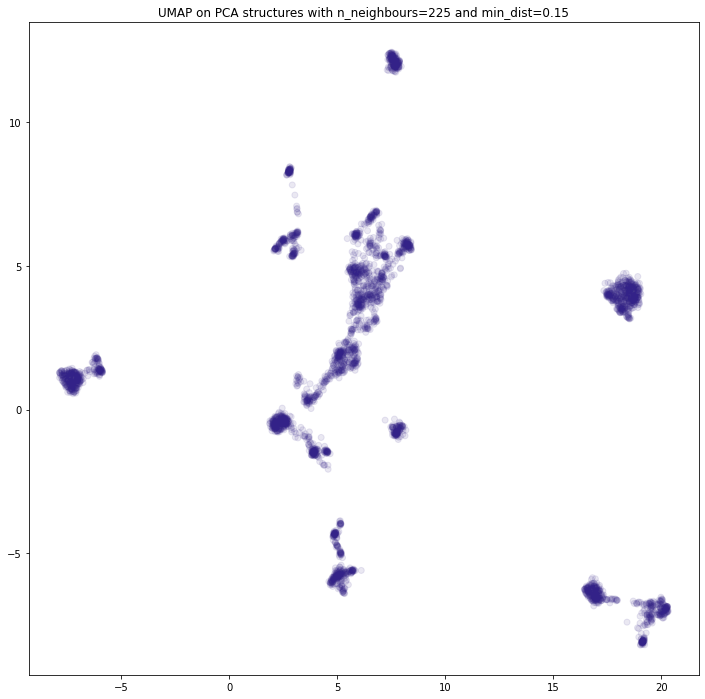

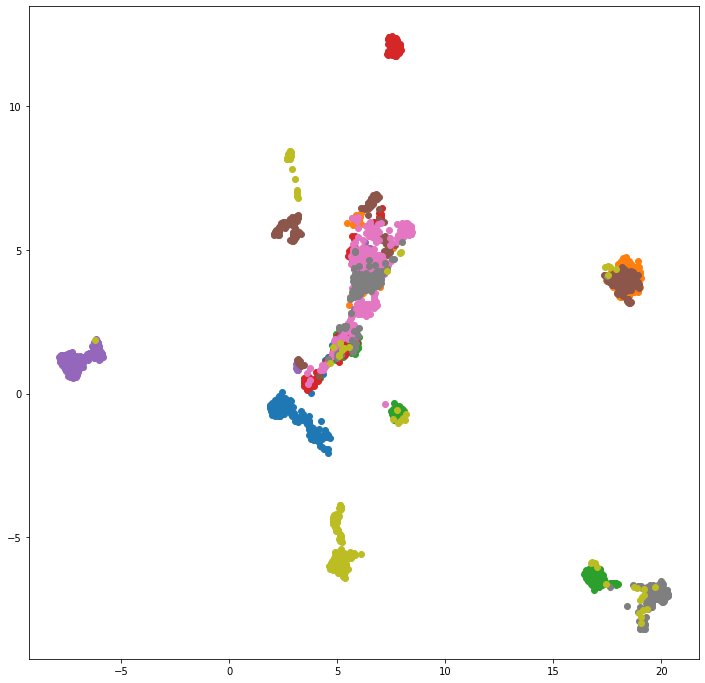

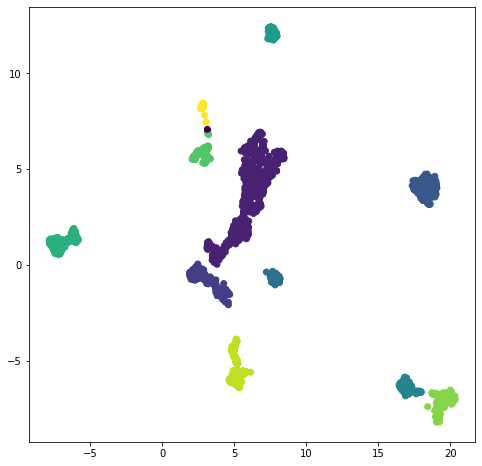

In [12]:
v2reducer = umap.UMAP(n_neighbors=225,
                                min_dist=0.15,
                                transform_seed = 1,
                                random_state = 1)

v2embedding = reducer.fit_transform(v2Z)


figure(figsize = (12,12))

scatter(*v2embedding.T,color = v2pca_colours,alpha = 0.1)
title("UMAP on PCA structures with n_neighbours="+str(225)+" and min_dist="+str(0.15))

figure(figsize = (12,12))
for i in range(9):
    scatter(array(v2embedding).reshape(-1,2).T[0].T[i*400:400*(i+1)],array(v2embedding).reshape(-1,2).T[1].T[i*400:400*(i+1)])
from sklearn.cluster import DBSCAN


v2db = DBSCAN(eps=.75,min_samples = 50).fit(array(v2embedding).reshape(-1,2))
figure(figsize = (8,8))
scatter(array(v2embedding).reshape(-1,2).T[0],array(v2embedding).reshape(-1,2).T[1],c = v2db.labels_)



C:\Users\Liam\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


Text(27.0, 0.5, 'V2 State')

<Figure size 1008x864 with 0 Axes>

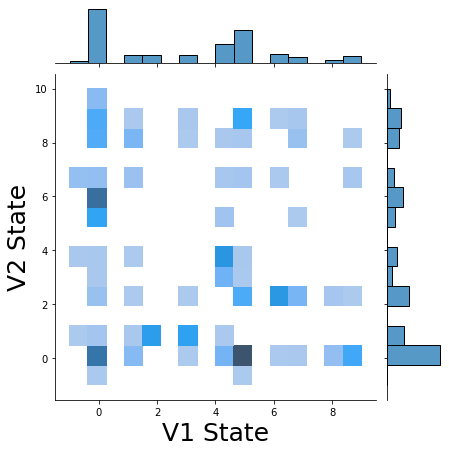

In [40]:
figure(figsize = (14,12))
sns.jointplot(v1db.labels_,v2db.labels_,kind = 'hist')
xlabel("V1 State",fontsize = 25)
ylabel("V2 State",fontsize = 25)
#c=colorbar()
